In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#import dataset
df = pd.read_csv("/content/Sales.csv")
df.head()

,Order_ID,Order_Date,Product_Name,Category,Region,Quantity,Unit_Price,Revenue
0,ORD00001,06/06/2024,Product_10,Home,West,7,130.50,913.50
1,ORD00002,02/01/2024,Product_27,Home,Central,3,277.16,831.48
2,ORD00003,22/11/2024,Product_6,Clothing,Central,9,113.64,1022.76
3,ORD00004,17/05/2024,Product_20,Clothing,Central,2,295.88,591.76
4,ORD00005,11/04/2024,Product_22,Sports,East,6,134.32,805.92


In [ ]:
#Check & Remove Duplicates
df.duplicated().sum()
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
#Check Missing Values
df.isnull().sum()
df = df.dropna()
print(df.isnull().sum())

Order_ID        0
Order_Date      0
Product_Name    0
Category        0
Region          0
Quantity        0
Unit_Price      0
Revenue         0
dtype: int64


In [ ]:
#Fix Invalid Financial Values
df = df[(df['Revenue'] >= 0) &
        (df['Unit_Price'] >= 0) &
        (df['Quantity'] >= 0)]

In [ ]:
#Convert Date
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Month'] = df['Order_Date'].dt.to_period('M')

In [ ]:
#Calculate KPIs
total_revenue = df['Revenue'].sum()
average_unit_price = df['Unit_Price'].mean()
print("Total Revenue:", total_revenue)
print("Average Unit Price:", average_unit_price)

Total Revenue: 1377633.79
Average Unit Price: 250.77598


In [ ]:
#Monthly Growth Rate
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_growth = monthly_revenue.pct_change()*100
print(monthly_revenue)
print(monthly_growth)

Month
2024-01    104195.63
2024-02    119578.71
2024-03    113091.35
2024-04    141063.41
2024-05     87951.75
2024-06    135637.59
2024-07     90805.87
2024-08    160243.99
2024-09     97594.19
2024-10    126478.38
2024-11    111554.91
2024-12     89438.01
Freq: M, Name: Revenue, dtype: float64
Month
2024-01          NaN
2024-02    14.763652
2024-03    -5.425180
2024-04    24.734040
2024-05   -37.650912
2024-06    54.218182
2024-07   -33.052578
2024-08    76.468757
2024-09   -39.096505
2024-10    29.596219
2024-11   -11.799226
2024-12   -19.826021
Freq: M, Name: Revenue, dtype: float64


/tmp/ipykernel_407/1568003012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products.reset_index(), x='Product_Name', y='Revenue', palette='viridis')


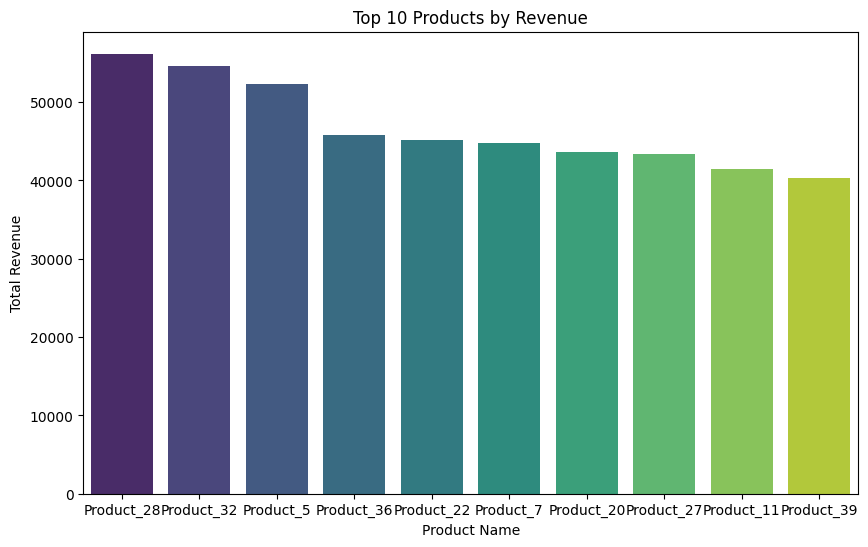

In [ ]:
top_products = df.groupby('Product_Name')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products.reset_index(), x='Product_Name', y='Revenue', palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.savefig('top_products_revenue.png')
plt.show()

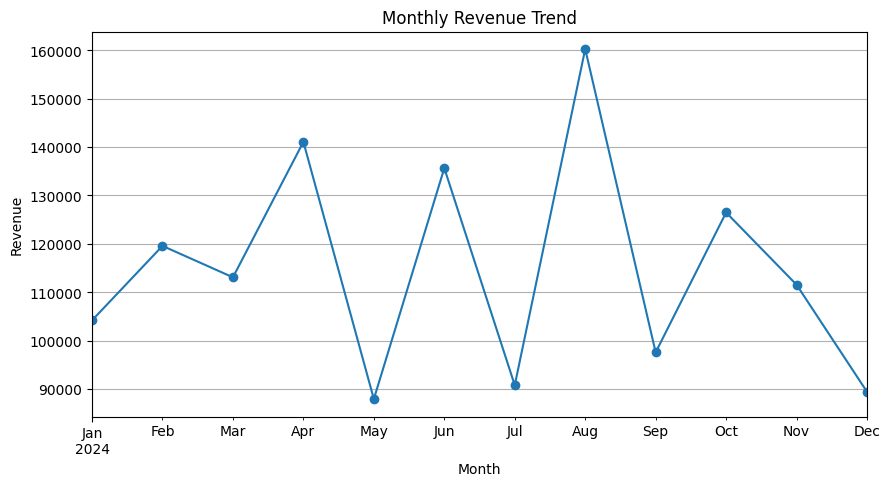

In [ ]:
#Line Chart – Monthly Revenue Trend
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

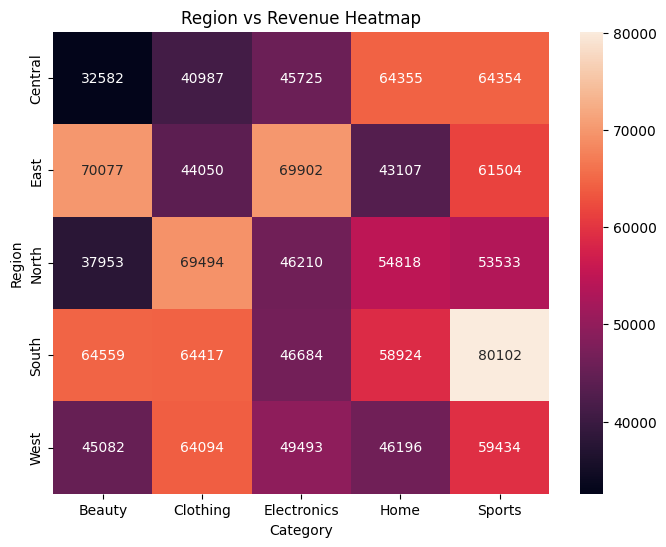

In [ ]:
#Heatmap – Region vs Revenue
pivot = df.pivot_table(
    values='Revenue',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Region vs Revenue Heatmap")
plt.show()

In [ ]:
df.to_csv("clean_sales_data.csv", index=False)